In [ ]:
# ==========================================
#  1: SETUP & MODEL LOADING
# ==========================================
!pip install open_clip_torch > /dev/null

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
import cv2
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from sklearn.metrics import (roc_auc_score, accuracy_score, confusion_matrix,
                             roc_curve, recall_score, f1_score, balanced_accuracy_score)
import matplotlib.pyplot as plt
import seaborn as sns
import open_clip
from PIL import Image

# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Paths
base_path = "/content/drive/MyDrive/MrNet-v1/MRNet-v1.0"
axial_dir = base_path + "/merged_data/axial"
coronal_dir  = base_path + "/merged_data/coronal"
sagittal_dir = base_path + "/merged_data/sagittal"


train_df = pd.read_csv(base_path + "/train_split.csv")
val_df   = pd.read_csv(base_path + "/val_split.csv")
test_df  = pd.read_csv(base_path + "/test_split.csv")

print(f"Dataset Sizes - Train: {len(train_df)}, Valid: {len(val_df)}, Test: {len(test_df)}")
plane_dirs = {"axial": axial_dir, "coronal": coronal_dir, "sagittal": sagittal_dir}

# Load BioMedCLIP (We will freeze this entirely later)
print("Loading BioMedCLIP...")
model_name = 'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224'
clip_model, _, preprocess = open_clip.create_model_and_transforms(model_name)
clip_model = clip_model.to(device)
tokenizer = open_clip.get_tokenizer(model_name)
print("Loaded successfully!")

Mounted at /content/drive
Using device: cuda
Dataset Sizes - Train: 875, Valid: 125, Test: 250
Loading BioMedCLIP...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

open_clip_pytorch_model.bin:   0%|          | 0.00/784M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Loaded successfully!


In [ ]:
# ==========================================
# 2: DATASET & AUGMENTATIONS
# ==========================================

# We apply spatial augmentations specifically designed for MRIs (from your ViT code)
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    # Note: We do NOT use ImageNet normalization here because BioMedCLIP's
    # `preprocess` function handles its own specific normalization internally.
])

class CoOpMRNetDataset(Dataset):
    def __init__(self, df, plane_dir, is_train=False):
        self.df = df
        self.plane_dir = plane_dir
        self.is_train = is_train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        patient_id = str(self.df.iloc[idx]["id"]).zfill(4)
        label = self.df.iloc[idx]["label"]

        vol = np.load(os.path.join(self.plane_dir, patient_id + ".npy"))

        # ENSEMBLE 4 PREPROCESSING: Volume-Level Min-Max Normalization
        vol = (vol - vol.min()) / (vol.max() - vol.min() + 1e-6)

        processed_slices = []
        for i in range(vol.shape[0]):
            slice_img = cv2.resize(vol[i], (224, 224))
            slice_img = (slice_img * 255).astype(np.uint8)
            slice_rgb = np.stack((slice_img,)*3, axis=-1)

            if self.is_train:
                # Apply augmentations during training
                slice_rgb = np.array(train_transform(slice_rgb))

            # Use BioMedCLIP's exact preprocessing to maintain VLM alignment
            img_pil = Image.fromarray(slice_rgb)
            img_tensor = preprocess(img_pil)
            processed_slices.append(img_tensor)

        return torch.stack(processed_slices), torch.tensor(label, dtype=torch.long), patient_id

# Sampler to handle MRNet Class Imbalance (From your ViT code)
labels = train_df["label"].values
class_counts = np.bincount(labels)
sample_weights = (1. / class_counts)[labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

In [ ]:
# ==========================================
# CELL 3: CONTEXT OPTIMIZATION (CoOp) MODULE
# ==========================================

class CoOpPromptLearner(nn.Module):
    def __init__(self, clip_model, tokenizer, n_ctx=16):
        super().__init__()
        self.n_ctx = n_ctx

        # 1. Get the actual word embedding layer from BiomedCLIP's BERT
        self.word_embeddings = clip_model.text.transformer.embeddings.word_embeddings
        embed_dim = self.word_embeddings.embedding_dim # 768 for PubMedBERT

        # 2. Initialize learnable context vectors
        ctx_vectors = torch.empty(n_ctx, embed_dim)
        nn.init.normal_(ctx_vectors, std=0.02)
        self.ctx = nn.Parameter(ctx_vectors)

        # 3. Prepare the class names
        classnames = ["intact normal anterior cruciate ligament", "complete tear of the anterior cruciate ligament"]

        # Tokenize the class names (BioMedCLIP defaults to 256 length)
        tokenized_classes = tokenizer(classnames).to(device)
        self.tokenized_classes = tokenized_classes

        # Extract embeddings for the text tokens
        with torch.no_grad():
            class_embeddings = self.word_embeddings(tokenized_classes) # Shape: [2, 256, 768]

        # We need to construct: [CLS] + [ctx_1 ... ctx_16] + [class_name] + [PADs]
        self.register_buffer("token_prefix", class_embeddings[:, :1, :])  # The [CLS] token

        # To make room for the 16 ctx tokens and keep total length at 256,
        # we drop 16 padding tokens from the very end.
        self.register_buffer("token_suffix", class_embeddings[:, 1 : 256 - n_ctx, :])

    def forward(self):
        # ctx shape: (n_ctx, dim) -> (batch_size, n_ctx, dim)
        ctx = self.ctx.unsqueeze(0).expand(2, -1, -1)

        # Concat: [2, 1, 768] + [2, 16, 768] + [2, 239, 768] = [2, 256, 768]
        prompts = torch.cat([self.token_prefix, ctx, self.token_suffix], dim=1)

        return prompts

class CoOpBioMedCLIP(nn.Module):
    def __init__(self, clip_model, tokenizer, n_ctx=16):
        super().__init__()
        self.clip_model = clip_model
        self.prompt_learner = CoOpPromptLearner(clip_model, tokenizer, n_ctx)

        # FREEZE the entire VLM
        for param in self.clip_model.parameters():
            param.requires_grad = False

    def forward(self, image_volume):
        # 1. Get Learnable Text Features
        prompts_embeds = self.prompt_learner()

        # Fix the Attention Mask for the inserted tokens!
        # Because we inserted n_ctx tokens, we need to extend the attention mask.
        original_mask = (self.prompt_learner.tokenized_classes != 0).long()
        original_lengths = original_mask.sum(dim=1)
        new_lengths = original_lengths + self.prompt_learner.n_ctx

        # Create a new 256-length mask matching the shifted tokens
        batch_size, seq_len = original_mask.shape
        arange_tensor = torch.arange(seq_len, device=prompts_embeds.device).expand(batch_size, seq_len)
        attention_mask = (arange_tensor < new_lengths.unsqueeze(1)).long()

        # Pass into PubMedBERT
        text_outputs = self.clip_model.text.transformer(
            inputs_embeds=prompts_embeds,
            attention_mask=attention_mask
        )

        cls_feats = text_outputs.last_hidden_state[:, 0, :]
        text_features = self.clip_model.text.proj(cls_feats)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

        # 2. Get Image Features
        image_features = self.clip_model.encode_image(image_volume)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        # Mean pooling
        patient_image_feature = image_features.mean(dim=0, keepdim=True)
        patient_image_feature = patient_image_feature / patient_image_feature.norm(dim=-1, keepdim=True)

        # 3. Calculate similarity
        logit_scale = self.clip_model.logit_scale.exp()
        logits = logit_scale * patient_image_feature @ text_features.t()

        return logits

In [ ]:
# ==========================================
#  4: CoOp TRAINING LOOP
# ==========================================

def train_coop_model(planes, epochs=10, n_ctx=16):
    # CrossEntropyLoss expects logits of shape (batch, 2) and labels of shape (batch)
    criterion = nn.CrossEntropyLoss()

    for plane_name, plane_dir in planes:
        print(f"\n" + "="*50 + f"\n STARTING CoOp: SOFT PROMPT TUNING ({plane_name.upper()})\n" + "="*50)

        train_ds = CoOpMRNetDataset(train_df, plane_dir, is_train=True)
        val_ds   = CoOpMRNetDataset(val_df, plane_dir, is_train=False)



        train_loader = DataLoader(train_ds, batch_size=1, sampler=sampler, num_workers=2, pin_memory=True)
        val_loader   = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=2, pin_memory=True)

        model = CoOpBioMedCLIP(clip_model, tokenizer, n_ctx=n_ctx).to(device)

        # OPTIMIZER: ONLY train the prompt context vectors!
        optimizer = optim.AdamW(model.prompt_learner.parameters(), lr=0.002, weight_decay=1e-4)
        scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)

        best_auc = 0.0

        for epoch in range(epochs):
            model.train()
            t_loss, t_correct, t_total = 0, 0, 0

            for imgs, lbls, _ in train_loader:
                imgs, lbls = imgs.squeeze(0).to(device), lbls.to(device)
                optimizer.zero_grad()

                logits = model(imgs) # Shape: (1, 2)
                loss = criterion(logits, lbls)
                loss.backward()
                optimizer.step()

                t_loss += loss.item()
                preds = logits.argmax(dim=1)
                t_correct += (preds == lbls).sum().item()
                t_total += 1

            scheduler.step()

            # Validation Phase
            model.eval()
            v_loss, v_correct, v_total, y_true, y_probs = 0, 0, 0, [], []
            with torch.no_grad():
                for imgs, lbls, _ in val_loader:
                    imgs, lbls = imgs.squeeze(0).to(device), lbls.to(device)

                    logits = model(imgs)
                    v_loss += criterion(logits, lbls).item()

                    # Convert logits to probabilities (Softmax)
                    probs = logits.softmax(dim=-1)
                    prob_tear = probs[0, 1].item() # Probability of class 1 (Tear)

                    y_true.append(lbls.item())
                    y_probs.append(prob_tear)

                    pred = logits.argmax(dim=1).item()
                    if pred == lbls.item(): v_correct += 1
                    v_total += 1

            auc = roc_auc_score(y_true, y_probs)

            print(f"Epoch [{epoch+1}/{epochs}] | LR: {scheduler.get_last_lr()[0]:.2e}")
            print(f"  [Train] Loss: {t_loss/t_total:.4f} | Acc: {(t_correct/t_total)*100:.2f}%")
            print(f"  [Val]   Loss: {v_loss/v_total:.4f} | Acc: {(v_correct/v_total)*100:.2f}% | AUC: {auc:.4f}")
            print("-" * 45)

            # Save best prompt embeddings based on Validation AUC
            if auc > best_auc:
                best_auc = auc
                save_path = os.path.join(base_path, f"coop_{plane_name}_best_prompts.pth")
                # We only save the prompt learner parameters, not the massive 1.5GB VLM
                torch.save(model.prompt_learner.state_dict(), save_path)
                print("  => New Best Prompts Saved!")

# Train on all three planes (you can start with just sagittal to test)
target_planes = [("sagittal", sagittal_dir), ("coronal", coronal_dir), ("axial", axial_dir)]
train_coop_model(target_planes, epochs=10, n_ctx=16)


 STARTING CoOp: SOFT PROMPT TUNING (SAGITTAL)
Epoch [1/10] | LR: 1.95e-03
  [Train] Loss: 0.7233 | Acc: 55.31%
  [Val]   Loss: 0.6267 | Acc: 68.80% | AUC: 0.6884
---------------------------------------------
  => New Best Prompts Saved!
Epoch [2/10] | LR: 1.81e-03
  [Train] Loss: 0.6281 | Acc: 65.71%
  [Val]   Loss: 0.4825 | Acc: 78.40% | AUC: 0.7137
---------------------------------------------
  => New Best Prompts Saved!
Epoch [3/10] | LR: 1.59e-03
  [Train] Loss: 0.6350 | Acc: 65.94%
  [Val]   Loss: 0.6191 | Acc: 69.60% | AUC: 0.6908
---------------------------------------------
Epoch [4/10] | LR: 1.31e-03
  [Train] Loss: 0.6376 | Acc: 64.69%
  [Val]   Loss: 0.5073 | Acc: 76.00% | AUC: 0.6915
---------------------------------------------
Epoch [5/10] | LR: 1.01e-03
  [Train] Loss: 0.6108 | Acc: 68.11%
  [Val]   Loss: 0.5903 | Acc: 72.00% | AUC: 0.7040
---------------------------------------------
Epoch [6/10] | LR: 6.98e-04
  [Train] Loss: 0.5961 | Acc: 69.03%
  [Val]   Loss: 0.54

Extracting CoOp features for SAGITTAL...
Extracting CoOp features for CORONAL...
Extracting CoOp features for AXIAL...

CoOp ENSEMBLE RESULTS (Weighted Fusion)
Optimal decision threshold found: 0.3469
Accuracy:           0.6640
Balanced Accuracy:  0.7247
AUC:                0.7729
Sensitivity:        0.8302 (Recall for Tears)
Specificity:        0.6193 (Recall for Healthy)
F1-Score:           0.5116
Confusion Matrix:   TN=122, FP=75, FN=9, TP=44



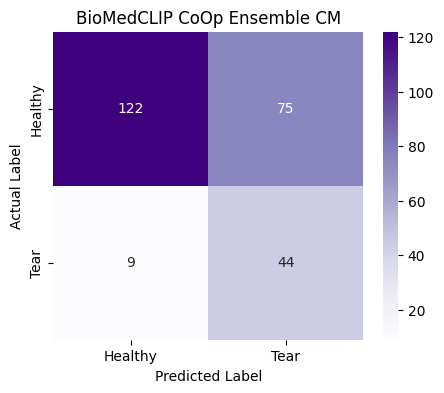

In [ ]:
# ==========================================
#  5: RADIOLOGY-WEIGHTED EVALUATION
# ==========================================

def extract_coop_probabilities(plane_name, plane_dir, weight_file):
    print(f"Extracting CoOp features for {plane_name.upper()}...")

    model = CoOpBioMedCLIP(clip_model, tokenizer, n_ctx=16).to(device)
    weights_path = os.path.join(base_path, weight_file)
    model.prompt_learner.load_state_dict(torch.load(weights_path, map_location=device))
    model.eval()

    # CRITICAL CHANGE: Use test_df here!
    dataset = CoOpMRNetDataset(test_df, plane_dir, is_train=False)
    loader = DataLoader(dataset, batch_size=1, shuffle=False)

    patient_probs = []
    labels = []

    with torch.no_grad():
        for imgs, lbl, p_id in loader:
            imgs = imgs.squeeze(0).to(device)
            lbl = lbl.item()

            logits = model(imgs)
            probs = logits.softmax(dim=-1)
            prob_tear = probs[0, 1].cpu().numpy()

            patient_probs.append(prob_tear)
            labels.append(lbl)

    return np.array(patient_probs), np.array(labels)

# 1. Gather CoOp probabilities for all planes
s_probs, y_true = extract_coop_probabilities("sagittal", sagittal_dir, "coop_sagittal_best_prompts.pth")
c_probs, _      = extract_coop_probabilities("coronal", coronal_dir, "coop_coronal_best_prompts.pth")
a_probs, _      = extract_coop_probabilities("axial", axial_dir, "coop_axial_best_prompts.pth")

# 2. Radiology-Weighted Multi-Plane Fusion
ensemble_probs = (0.6 * s_probs) + (0.3 * c_probs) + (0.1 * a_probs)

# 3. Find optimal threshold using Youden's J statistic
fpr, tpr, thresholds = roc_curve(y_true, ensemble_probs)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print(f"\n" + "="*50)
print("CoOp ENSEMBLE RESULTS (Weighted Fusion)")
print("="*50)
print(f"Optimal decision threshold found: {optimal_threshold:.4f}")

final_preds = (ensemble_probs >= optimal_threshold).astype(int)

# Metrics
acc = accuracy_score(y_true, final_preds)
bal_acc = balanced_accuracy_score(y_true, final_preds)
auc = roc_auc_score(y_true, ensemble_probs)
sens = recall_score(y_true, final_preds)
f1 = f1_score(y_true, final_preds)
tn, fp, fn, tp = confusion_matrix(y_true, final_preds).ravel()
spec = tn / (tn + fp) if (tn + fp) > 0 else 0

print(f"Accuracy:           {acc:.4f}")
print(f"Balanced Accuracy:  {bal_acc:.4f}")
print(f"AUC:                {auc:.4f}")
print(f"Sensitivity:        {sens:.4f} (Recall for Tears)")
print(f"Specificity:        {spec:.4f} (Recall for Healthy)")
print(f"F1-Score:           {f1:.4f}")
print(f"Confusion Matrix:   TN={tn}, FP={fp}, FN={fn}, TP={tp}\n")

# Confusion Matrix Heatmap
cm = confusion_matrix(y_true, final_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['Healthy', 'Tear'], yticklabels=['Healthy', 'Tear'])
plt.title("BioMedCLIP CoOp Ensemble CM")
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

Visualizing Patient Index: 3


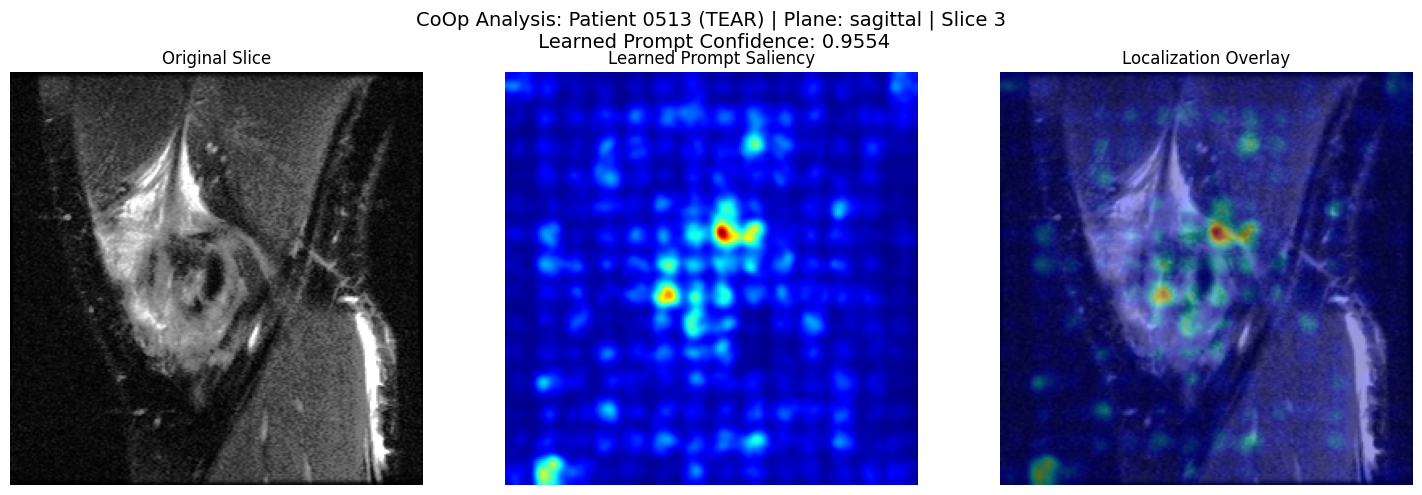

In [ ]:
# ==========================================
# 6: CoOp EXPLAINABILITY (SALIENCY MAPS)
# ==========================================

def generate_coop_saliency_heatmap(model, img_tensor):
    """
    Generates a saliency map based on the similarity between
    the image and the LEARNED CoOp 'Tear' prompt.
    """
    model.eval()

    # 1. Get the learned text features from the CoOp module
    # In CoOpBioMedCLIP, model() returns (batch, 2)
    # We want to maximize the logit for Class 1 (Tear)

    # Prepare image tensor for gradients
    single_slice = img_tensor.clone().detach().to(device)
    single_slice.requires_grad_()

    # Forward pass: Image Encoder
    image_features = model.clip_model.encode_image(single_slice)
    image_features = image_features / image_features.norm(dim=-1, keepdim=True)

    # Forward pass: Get learned text features (Prompt Learner)
    prompts_embeds = model.prompt_learner()

    # Handle Attention Mask logic (same as in forward)
    original_mask = (model.prompt_learner.tokenized_classes != 0).long()
    new_lengths = original_mask.sum(dim=1) + model.prompt_learner.n_ctx
    arange_tensor = torch.arange(256, device=device).expand(2, 256)
    attention_mask = (arange_tensor < new_lengths.unsqueeze(1)).long()

    text_outputs = model.clip_model.text.transformer(
        inputs_embeds=prompts_embeds,
        attention_mask=attention_mask
    )
    cls_feats = text_outputs.last_hidden_state[:, 0, :]
    text_features = model.clip_model.text.proj(cls_feats)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

    # Isolate the "Tear" feature (index 1)
    tear_text_feature = text_features[1:2]

    # Calculate similarity
    logit_scale = model.clip_model.logit_scale.exp()
    similarity = (logit_scale * image_features @ tear_text_feature.t()).squeeze()

    # Backpropagate similarity score to image pixels
    model.zero_grad()
    similarity.backward()

    # Extract gradients
    saliency = single_slice.grad.data.abs().squeeze().cpu().numpy()
    if len(saliency.shape) == 3: # (C, H, W)
        saliency = np.max(saliency, axis=0) # Max over RGB channels

    # Smooth and Normalize
    saliency = cv2.GaussianBlur(saliency, (11, 11), 0)
    if saliency.max() != saliency.min():
        saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)

    heatmap = np.uint8(255 * saliency)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    return heatmap_color

def visualize_coop_prediction(patient_idx, plane="sagittal"):
    """
    Finds the most suspicious slice using the CoOp model and visualizes attention.
    """
    # 1. Load the model and best learned prompts
    plane_dir = plane_dirs[plane]
    weight_file = f"coop_{plane}_best_prompts.pth"

    coop_model = CoOpBioMedCLIP(clip_model, tokenizer, n_ctx=16).to(device)
    coop_model.prompt_learner.load_state_dict(torch.load(os.path.join(base_path, weight_file), map_location=device))
    coop_model.eval()

    # 2. Get patient info
    patient_id = str(test_df.iloc[patient_idx]["id"]).zfill(4)
    true_label = test_df.iloc[patient_idx]["label"]
    vol = np.load(os.path.join(plane_dir, patient_id + ".npy"))

    # 3. Find most suspicious slice
    # Normalize volume exactly like training
    vol_norm = (vol - vol.min()) / (vol.max() - vol.min() + 1e-6)

    slice_probs = []
    processed_tensors = []

    with torch.no_grad():
        for i in range(vol_norm.shape[0]):
            img = cv2.resize(vol_norm[i], (224, 224))
            img_255 = (img * 255).astype(np.uint8)
            img_rgb = np.stack((img_255,)*3, axis=-1)
            img_tensor = preprocess(Image.fromarray(img_rgb)).unsqueeze(0).to(device)

            # Use whole patient logic or per-slice similarity
            # Here we calculate per-slice similarity to find the 'peak' slice
            image_feat = coop_model.clip_model.encode_image(img_tensor)
            image_feat /= image_feat.norm(dim=-1, keepdim=True)

            # Calculate logits for this specific slice
            logits = coop_model(img_tensor)
            prob_tear = torch.softmax(logits, dim=-1)[0, 1].item()

            slice_probs.append(prob_tear)
            processed_tensors.append(img_tensor)

    # Find slice with highest tear probability
    best_slice_idx = np.argmax(slice_probs)
    target_tensor = processed_tensors[best_slice_idx]

    # 4. Generate Heatmap
    heatmap_img = generate_coop_saliency_heatmap(coop_model, target_tensor)

    # 5. Prepare Overlay
    original_slice_rgb = (cv2.resize(vol_norm[best_slice_idx], (224, 224)) * 255).astype(np.uint8)
    original_slice_rgb = np.stack((original_slice_rgb,)*3, axis=-1)
    overlay = cv2.addWeighted(original_slice_rgb, 0.6, heatmap_img, 0.4, 0)

    # 6. Plotting
    status = "TEAR" if true_label == 1 else "HEALTHY"
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"CoOp Analysis: Patient {patient_id} ({status}) | Plane: {plane} | Slice {best_slice_idx}\n Learned Prompt Confidence: {slice_probs[best_slice_idx]:.4f}", fontsize=14)

    axes[0].imshow(vol_norm[best_slice_idx], cmap='gray')
    axes[0].set_title("Original Slice")
    axes[0].axis('off')

    axes[1].imshow(cv2.cvtColor(heatmap_img, cv2.COLOR_BGR2RGB))
    axes[1].set_title("Learned Prompt Saliency")
    axes[1].axis('off')

    axes[2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    axes[2].set_title("Localization Overlay")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

# --- RUN VISUALIZATION ---
# Select a patient from test_df (e.g., first patient with a tear)
tear_indices = test_df[test_df['label'] == 1].index.tolist()
if tear_indices:
    print(f"Visualizing Patient Index: {tear_indices[0]}")
    visualize_coop_prediction(patient_idx=tear_indices[0], plane="sagittal")
else:
    print("No tears found in test set to visualize.")